In [1]:
# Install required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_excel('/content/churn column.xlsx')

# Clean 'annual_income' and 'months_active' columns
# Remove commas and convert to numeric, coercing errors to NaN
df['annual_income'] = pd.to_numeric(df['annual_income'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df['months_active'] = pd.to_numeric(df['months_active'].astype(str).str.replace(',', '', regex=False), errors='coerce')

# Encode target: Yes -> 1, No -> 0
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
# Drop any rows where churn might have become NaN due to non 'Yes'/'No' values after mapping
df = df.dropna(subset=['churn'])

# Categorical columns to encode
cat_cols = ['payment_method', 'region', 'customer_segment']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Handle any remaining missing values after cleaning (e.g., if conversion to float resulted in NaNs)
# For simplicity, we'll drop rows with NaNs. A more robust solution might involve imputation.
df = df.dropna()

print("Shape after full cleaning and encoding:", df.shape)
print("\nFirst 3 rows after cleaning and encoding:")
print(df.head(3))
print("\nData types after full cleaning and encoding:")
print(df.dtypes)
print("\nMissing values after full cleaning and encoding:")
print(df.isnull().sum())

Shape after full cleaning and encoding: (49476, 15)

First 3 rows after cleaning and encoding:
   customer_id  age  annual_income  months_active  avg_monthly_spend  \
0        33554   53         100473             63             121.43   
1         9428   54          54731             67             572.55   
2          200   44          58268             57             266.59   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0                 0.8            66.82                0.117        0.023   
1                 3.2           137.09                0.262        0.429   
2                 2.7            71.80                0.285        0.012   

   browsing_time_minutes  support_interactions  payment_method  region  \
0                   77.3                     2               0       1   
1                   92.1                     2               2       2   
2                  155.2                     1               1       0   

   customer_se

In [6]:
df_cleaned = df.dropna(subset=['churn']).copy()
X = df_cleaned.drop(columns=['churn'])
y = df_cleaned['churn']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"\nChurn distribution in test set:\n{y_test.value_counts()}")

Train size : (39580, 14)
Test size  : (9896, 14)

Churn distribution in test set:
churn
0    9762
1     134
Name: count, dtype: int64


**LOGISTIC REGRESSION**


In [48]:
# Logistic Regression
scaler_before = StandardScaler()
X_train_sc_before = scaler_before.fit_transform(X_train)
X_test_sc_before  = scaler_before.transform(X_test)

log_reg_before = LogisticRegression(max_iter=1000, random_state=42)
log_reg_before.fit(X_train_sc_before, y_train)
y_pred_lr_before = log_reg_before.predict(X_test_sc_before)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr_before,
      target_names=['No Churn', 'Churn']))

Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.99      1.00      0.99      9762
       Churn       0.57      0.22      0.31       134

    accuracy                           0.99      9896
   macro avg       0.78      0.61      0.65      9896
weighted avg       0.98      0.99      0.98      9896



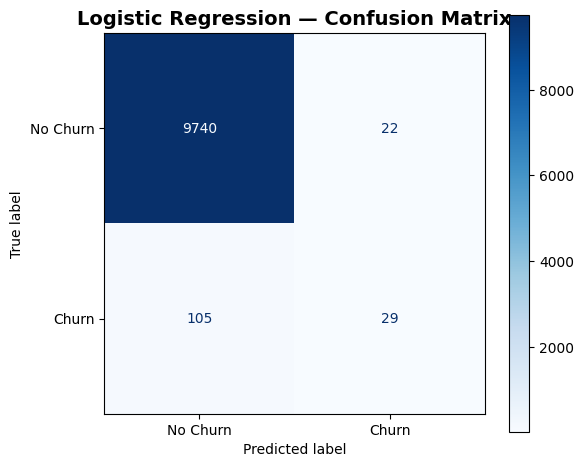

In [49]:
cm_lr_before = confusion_matrix(y_test, y_pred_lr_before)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr_before,
                               display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Logistic Regression — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

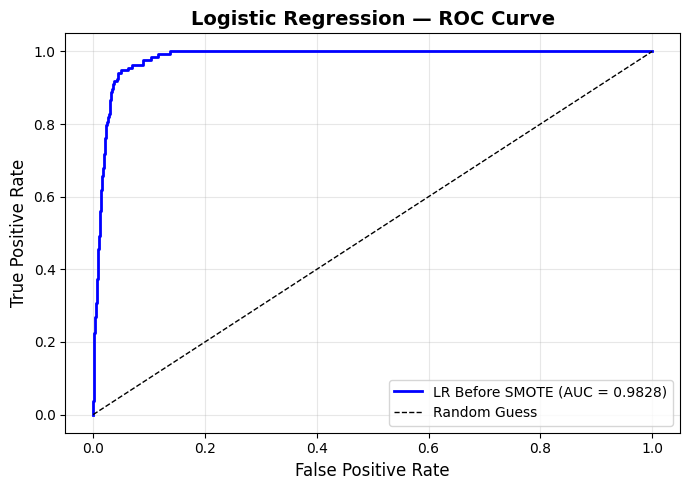

In [51]:
y_prob_lr_before = log_reg_before.predict_proba(X_test_sc_before)[:, 1]
fpr_lr_before, tpr_lr_before, _ = roc_curve(y_test, y_prob_lr_before)
auc_lr_before = auc(fpr_lr_before, tpr_lr_before)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr_before, tpr_lr_before, color='blue', linewidth=2,
         label=f'LR Before SMOTE (AUC = {auc_lr_before:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Logistic Regression — ROC Curve',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**DECISION TREE**


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)

In [10]:
dt_model = DecisionTreeClassifier(
    max_depth=6,           # controls overfitting
    min_samples_split=20,  # minimum samples to split a node
    min_samples_leaf=10,   # minimum samples in a leaf
    random_state=42
)

# Decision Tree does NOT need scaled data
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
# Decision Tree gives feature importances (not coefficients)
dt_imp_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

dt_imp_df['Rank']            = dt_imp_df.index + 1
dt_imp_df['Importance (%)']  = (dt_imp_df['Importance'] * 100).round(2)

print("=" * 55)
print("   📋 DECISION TREE — FEATURE IMPORTANCE TABLE")
print("=" * 55)
print(dt_imp_df[['Rank', 'Feature', 'Importance', 'Importance (%)']].to_string(index=False))
print("=" * 55)

print("✅ Decision Tree trained!")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))

   📋 DECISION TREE — FEATURE IMPORTANCE TABLE
 Rank               Feature  Importance  Importance (%)
    1     avg_monthly_spend    0.463770           46.38
    2    purchase_frequency    0.459744           45.97
    3         months_active    0.076486            7.65
    4           customer_id    0.000000            0.00
    5                   age    0.000000            0.00
    6         annual_income    0.000000            0.00
    7       avg_order_value    0.000000            0.00
    8   discount_usage_rate    0.000000            0.00
    9           return_rate    0.000000            0.00
   10 browsing_time_minutes    0.000000            0.00
   11  support_interactions    0.000000            0.00
   12        payment_method    0.000000            0.00
   13                region    0.000000            0.00
   14      customer_segment    0.000000            0.00
✅ Decision Tree trained!

Classification Report:
              precision    recall  f1-score   support

    No Chu

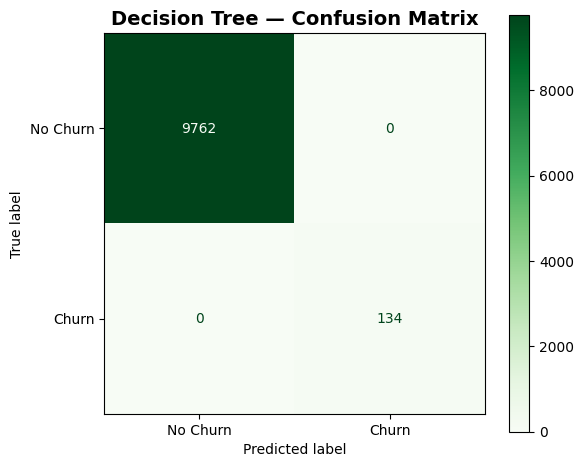

 Confusion Matrix saved!


In [11]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Decision Tree — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150)
plt.show()
print(" Confusion Matrix saved!")

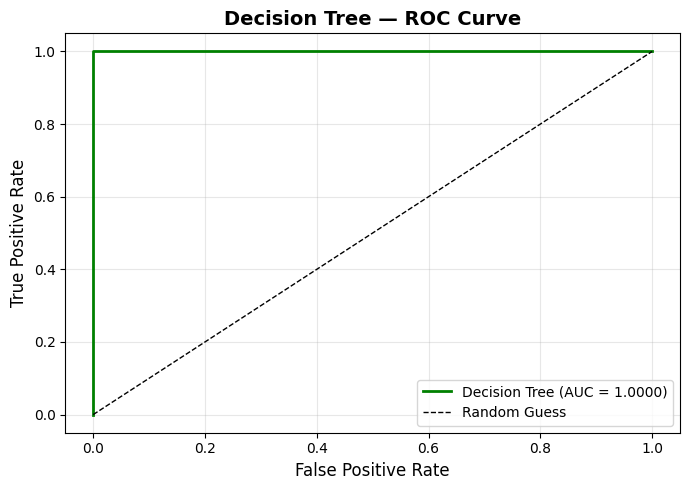

✅ ROC Curve saved! AUC = 1.0000


In [12]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, color='green', linewidth=2,
         label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Decision Tree — ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dt_roc_curve.png', dpi=150)
plt.show()
print(f"✅ ROC Curve saved! AUC = {auc_dt:.4f}")

**RANDOM FOREST**

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=10,          # max depth of each tree
    min_samples_split=20,  # minimum samples to split a node
    min_samples_leaf=10,   # minimum samples in a leaf
    random_state=42,
    n_jobs=-1              # use all CPU cores for speed
)

# Random Forest does NOT need scaled data
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
# Random Forest gives averaged feature importances across all trees
rf_imp_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_imp_df['Rank']           = rf_imp_df.index + 1
rf_imp_df['Importance (%)'] = (rf_imp_df['Importance'] * 100).round(2)

print("=" * 55)
print("   📋 RANDOM FOREST — FEATURE IMPORTANCE TABLE")
print("=" * 55)
print(rf_imp_df[['Rank', 'Feature', 'Importance', 'Importance (%)']].to_string(index=False))
print("=" * 55)

print("✅ Random Forest trained!")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

   📋 RANDOM FOREST — FEATURE IMPORTANCE TABLE
 Rank               Feature  Importance  Importance (%)
    1         months_active    0.389312           38.93
    2    purchase_frequency    0.270062           27.01
    3     avg_monthly_spend    0.180983           18.10
    4       avg_order_value    0.111450           11.15
    5           return_rate    0.008280            0.83
    6   discount_usage_rate    0.006803            0.68
    7         annual_income    0.006603            0.66
    8           customer_id    0.006514            0.65
    9 browsing_time_minutes    0.005800            0.58
   10                   age    0.004997            0.50
   11      customer_segment    0.004528            0.45
   12  support_interactions    0.001999            0.20
   13                region    0.001425            0.14
   14        payment_method    0.001245            0.12
✅ Random Forest trained!

Classification Report:
              precision    recall  f1-score   support

    No Chu

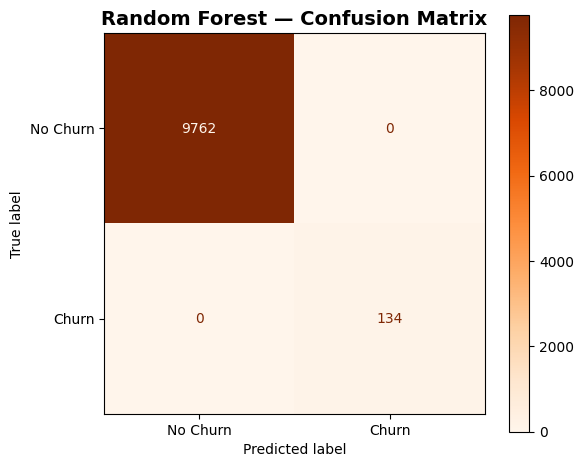

✅ Confusion Matrix saved!


In [15]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Oranges', ax=plt.gca())
plt.title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved!")

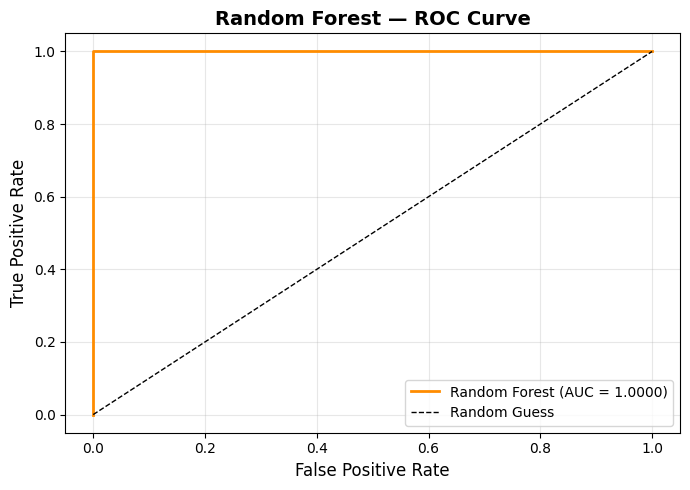

✅ ROC Curve saved! AUC = 1.0000


In [16]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color='darkorange', linewidth=2,
         label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest — ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rf_roc_curve.png', dpi=150)
plt.show()
print(f"✅ ROC Curve saved! AUC = {auc_rf:.4f}")

**CHECKING CORRELATION**

In [23]:
# The 'annual_income' column in df is already cleaned and converted to numeric (or dropped if NaN) in cell UVO9eRJNp3QK.
# No further cleaning is needed here.

# Check correlation of every feature with Churn
corr = df.corr()['churn'].abs().sort_values(ascending=False)
print("Feature Correlation with Churn:")
print(corr)

Feature Correlation with Churn:
churn                    1.000000
months_active            0.172173
purchase_frequency       0.128326
avg_monthly_spend        0.083557
avg_order_value          0.040906
customer_segment         0.038436
support_interactions     0.008894
browsing_time_minutes    0.007756
region                   0.007593
age                      0.005092
discount_usage_rate      0.004476
payment_method           0.002552
return_rate              0.001954
annual_income            0.001828
customer_id              0.001500
Name: churn, dtype: float64


In [24]:
# Check if any feature is perfectly correlated
print("\nSuspicious columns (correlation > 0.8):")
print(corr[corr > 0.8])


Suspicious columns (correlation > 0.8):
churn    1.0
Name: churn, dtype: float64


In [25]:
# Check feature importance of the shallow tree (depth=2)
dt_check = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_check.fit(X_train, y_train)

imp = pd.Series(dt_check.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False)
print("Feature Importances at Depth 2:")
print(imp)

Feature Importances at Depth 2:
purchase_frequency       0.857364
months_active            0.142636
age                      0.000000
customer_id              0.000000
annual_income            0.000000
avg_monthly_spend        0.000000
avg_order_value          0.000000
discount_usage_rate      0.000000
return_rate              0.000000
browsing_time_minutes    0.000000
support_interactions     0.000000
payment_method           0.000000
region                   0.000000
customer_segment         0.000000
dtype: float64


In [26]:
X = df.drop(columns=['churn', 'purchase_frequency'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Done! Shape:", X_train.shape, X_test.shape)

✅ Done! Shape: (39580, 13) (9896, 13)


**APPLYING SMOTE**

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
churn
0    39044
1    39044
Name: count, dtype: int64


**LOGISTIC AFTER SMOTE**

In [30]:
# Logistic Regression
scaler2 = StandardScaler()
X_train_sc = scaler2.fit_transform(X_train_sm)
X_test_sc  = scaler2.transform(X_test)

log_reg2 = LogisticRegression(max_iter=1000, random_state=42)
log_reg2.fit(X_train_sc, y_train_sm)
y_pred_lr2 = log_reg2.predict(X_test_sc)
y_prob_lr2 = log_reg2.predict_proba(X_test_sc)[:, 1]
coef_df = pd.DataFrame({
    'Feature'     : X.columns,
    'Coefficient' : log_reg2.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

coef_df.index += 1

print("=" * 45)
print("  LOGISTIC REGRESSION COEFFICIENTS TABLE")
print("=" * 45)
print(coef_df.to_string())
print("=" * 45)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr2,
      target_names=['No Churn', 'Churn']))

  LOGISTIC REGRESSION COEFFICIENTS TABLE
                  Feature  Coefficient
1         avg_order_value     3.072442
2     discount_usage_rate     0.187851
3   browsing_time_minutes     0.177921
4             customer_id    -0.017356
5           annual_income    -0.089810
6                     age    -0.119433
7    support_interactions    -0.207961
8             return_rate    -0.217148
9                  region    -0.467572
10         payment_method    -0.503540
11       customer_segment    -0.878630
12      avg_monthly_spend    -4.819164
13          months_active    -8.716292
Logistic Regression:
              precision    recall  f1-score   support

    No Churn       1.00      0.95      0.97      9762
       Churn       0.21      0.94      0.34       134

    accuracy                           0.95      9896
   macro avg       0.60      0.95      0.66      9896
weighted avg       0.99      0.95      0.97      9896



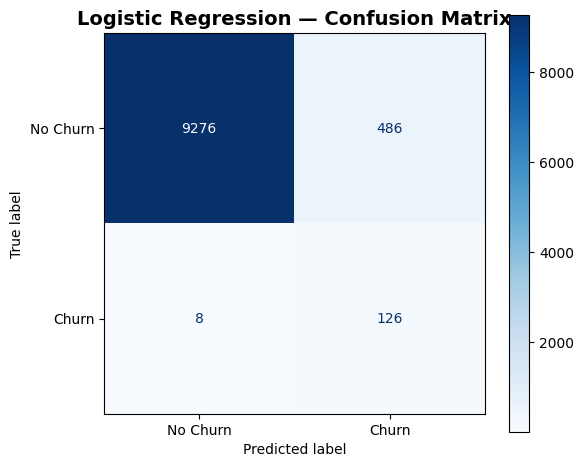

In [53]:
cm_lr = confusion_matrix(y_test, y_pred_lr2)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

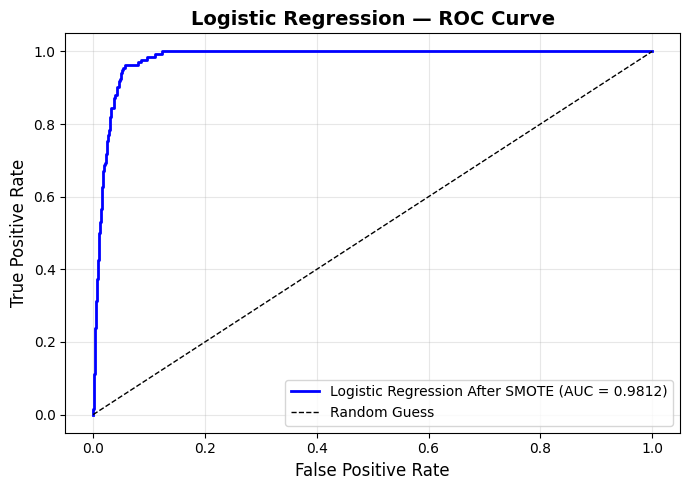

In [54]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr2)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='blue', linewidth=2,
         label=f'Logistic Regression After SMOTE (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Logistic Regression — ROC Curve',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**DECISION TREE AFTER SMOTE**

In [34]:
# Decision Tree
dt2 = DecisionTreeClassifier(max_depth=4, min_samples_split=50,
                              min_samples_leaf=20, random_state=42)
dt2.fit(X_train_sm, y_train_sm)
y_pred_dt2 = dt2.predict(X_test)
y_prob_dt2 = dt2.predict_proba(X_test)[:, 1]
dt_imp_df = pd.DataFrame({
    'Feature'        : X.columns,
    'Importance'     : dt2.feature_importances_,
    'Importance (%)' : (dt2.feature_importances_ * 100).round(2)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

dt_imp_df.index += 1

print("=" * 50)
print("   DECISION TREE FEATURE IMPORTANCE TABLE")
print("=" * 50)
print(dt_imp_df.to_string())
print("=" * 50)
print(" Decision Tree:")
print(classification_report(y_test, y_pred_dt2,
      target_names=['No Churn', 'Churn']))

   DECISION TREE FEATURE IMPORTANCE TABLE
                  Feature  Importance  Importance (%)
1           months_active    0.812619           81.26
2       avg_monthly_spend    0.138561           13.86
3         avg_order_value    0.048820            4.88
4           annual_income    0.000000            0.00
5             customer_id    0.000000            0.00
6                     age    0.000000            0.00
7     discount_usage_rate    0.000000            0.00
8             return_rate    0.000000            0.00
9   browsing_time_minutes    0.000000            0.00
10   support_interactions    0.000000            0.00
11         payment_method    0.000000            0.00
12                 region    0.000000            0.00
13       customer_segment    0.000000            0.00
 Decision Tree:
              precision    recall  f1-score   support

    No Churn       1.00      0.96      0.98      9762
       Churn       0.27      1.00      0.43       134

    accuracy          

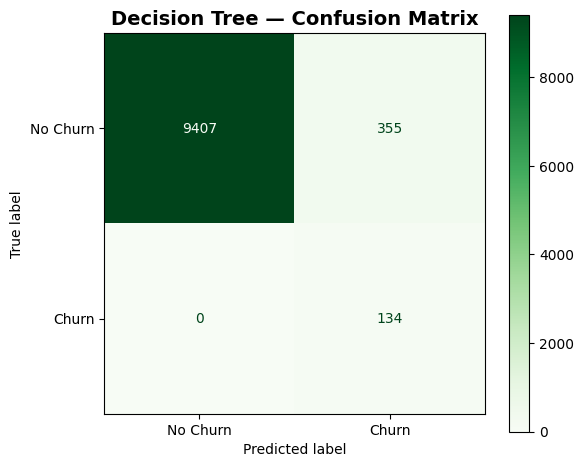

In [46]:
# Decision Tree Confusion Matrix after SMOTE fix
cm_dt2 = confusion_matrix(y_test, y_pred_dt2)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt2,
                               display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Decision Tree — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_confusion_matrix_fixed.png', dpi=150)
plt.show()

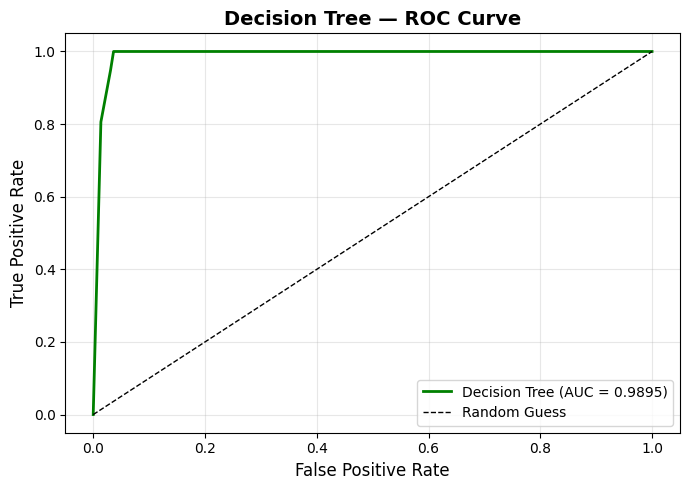

In [52]:
fpr_dt2, tpr_dt2, _ = roc_curve(y_test, y_prob_dt2)
auc_dt2 = auc(fpr_dt2, tpr_dt2)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt2, tpr_dt2, color='green',
         linewidth=2,
         label=f'Decision Tree (AUC = {auc_dt2:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Decision Tree — ROC Curve',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**RANDOM FOREST AFTER SMOTE**

In [41]:
# Random Forest AFTER SMOTE — Before Threshold Tuning
print("Random Forest AFTER SMOTE — Before Tuning:")
print(classification_report(y_test, y_pred_rf2,
      target_names=['No Churn', 'Churn']))

Random Forest AFTER SMOTE — Before Tuning:
              precision    recall  f1-score   support

    No Churn       1.00      0.99      0.99      9762
       Churn       0.44      0.87      0.59       134

    accuracy                           0.98      9896
   macro avg       0.72      0.93      0.79      9896
weighted avg       0.99      0.98      0.99      9896



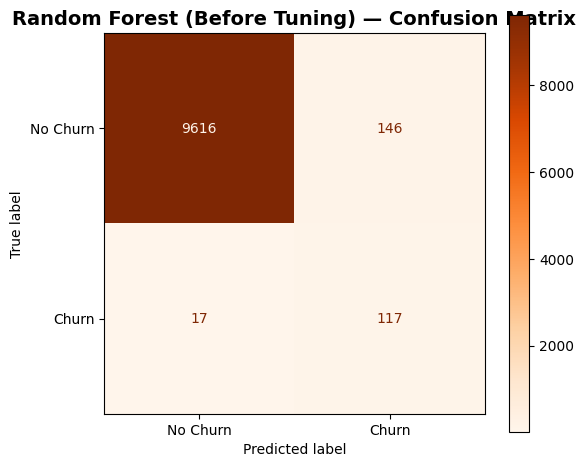

Confusion Matrix saved!


In [44]:
# Confusion Matrix — Before Tuning
cm_rf2 = confusion_matrix(y_test, y_pred_rf2)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf2,
                               display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Oranges', ax=plt.gca())
plt.title('Random Forest (Before Tuning) — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_before_tuning_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion Matrix saved!")

**RANDOM FOREST THRESHOLD**

In [43]:
# Tune threshold for Random Forest (best model)
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf2)

# Find best threshold where F1 is maximum
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[f1_scores.argmax()]
print(f"Best Threshold: {best_thresh:.4f}")

# Apply best threshold
y_pred_rf_tuned = (y_prob_rf2 >= best_thresh).astype(int)
rf_imp_df = pd.DataFrame({
    'Feature'        : X.columns,
    'Importance'     : rf2.feature_importances_,
    'Importance (%)' : (rf2.feature_importances_ * 100).round(2)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_imp_df.index += 1

print("=" * 50)
print("   RANDOM FOREST FEATURE IMPORTANCE TABLE")
print("=" * 50)
print(rf_imp_df.to_string())
print("=" * 50)

print("\n✅ Random Forest — Tuned Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned,
      target_names=['No Churn', 'Churn']))

Best Threshold: 0.6473
   RANDOM FOREST FEATURE IMPORTANCE TABLE
                  Feature  Importance  Importance (%)
1           months_active    0.502876           50.29
2       avg_monthly_spend    0.251902           25.19
3         avg_order_value    0.112243           11.22
4        customer_segment    0.058373            5.84
5          payment_method    0.021005            2.10
6                  region    0.019795            1.98
7     discount_usage_rate    0.006547            0.65
8                     age    0.005682            0.57
9    support_interactions    0.005141            0.51
10          annual_income    0.004936            0.49
11            customer_id    0.004422            0.44
12  browsing_time_minutes    0.004400            0.44
13            return_rate    0.002679            0.27

✅ Random Forest — Tuned Classification Report:
              precision    recall  f1-score   support

    No Churn       1.00      0.99      0.99      9762
       Churn       0.5

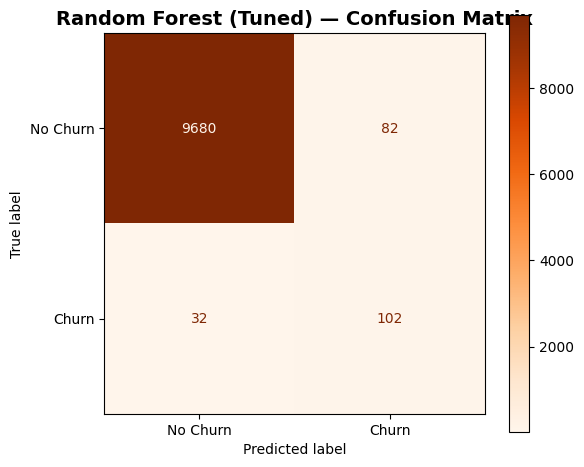

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned,
                               display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Oranges', ax=plt.gca())
plt.title('Random Forest (Tuned) — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_tuned_confusion_matrix.png', dpi=150)
plt.show()

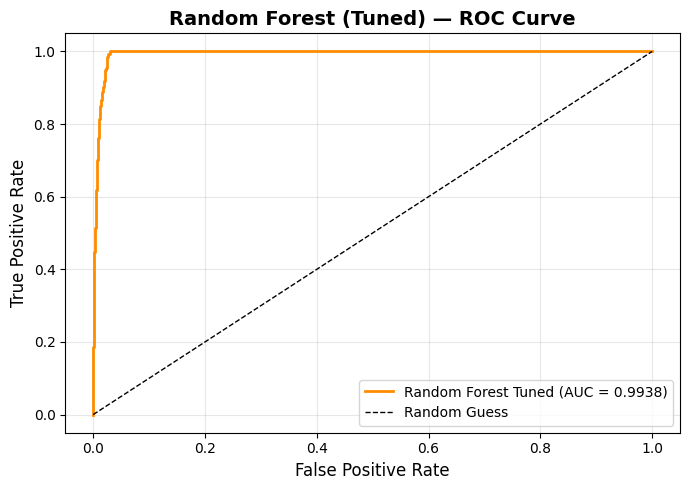

Tuned ROC Curve saved!


In [38]:
from sklearn.metrics import roc_curve, auc

fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_prob_rf2)
auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf_tuned, tpr_rf_tuned, color='darkorange', linewidth=2,
         label=f'Random Forest Tuned (AUC = {auc_rf_tuned:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest (Tuned) — ROC Curve',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rf_tuned_roc_curve.png', dpi=150)
plt.show()
print("Tuned ROC Curve saved!")

**FINAL MODEL COMPARISON**

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

results_final = []

models_info = [
    ('Logistic Regression',  y_pred_lr2,      y_prob_lr2),
    ('Decision Tree',        y_pred_dt2,       y_prob_dt2),
    ('Random Forest(Tuned)', y_pred_rf_tuned,  y_prob_rf2)
]

for name, pred, prob in models_info:
    fpr, tpr, _ = roc_curve(y_test, prob)
    results_final.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, pred),                   4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, pred),                     4),
        'F1-Score' : round(f1_score(y_test, pred),                         4),
        'AUC-ROC'  : round(auc(fpr, tpr),                                  4)
    })

final_df = pd.DataFrame(results_final).set_index('Model')

print("=" * 70)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 70)
print(final_df.to_string())
print("=" * 70)
print(f"\n Best Model by Accuracy : {final_df['Accuracy'].idxmax()}")
print(f" Best Model by AUC-ROC  : {final_df['AUC-ROC'].idxmax()}")
print(f" Best Model by F1-Score : {final_df['F1-Score'].idxmax()}")
print(f" Best Model by Recall   : {final_df['Recall'].idxmax()}")

FINAL MODEL COMPARISON TABLE
                      Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                               
Logistic Regression     0.9501     0.2059  0.9403    0.3378   0.9812
Decision Tree           0.9641     0.2740  1.0000    0.4302   0.9895
Random Forest(Tuned)    0.9885     0.5543  0.7612    0.6415   0.9938

 Best Model by Accuracy : Random Forest(Tuned)
 Best Model by AUC-ROC  : Random Forest(Tuned)
 Best Model by F1-Score : Random Forest(Tuned)
 Best Model by Recall   : Decision Tree


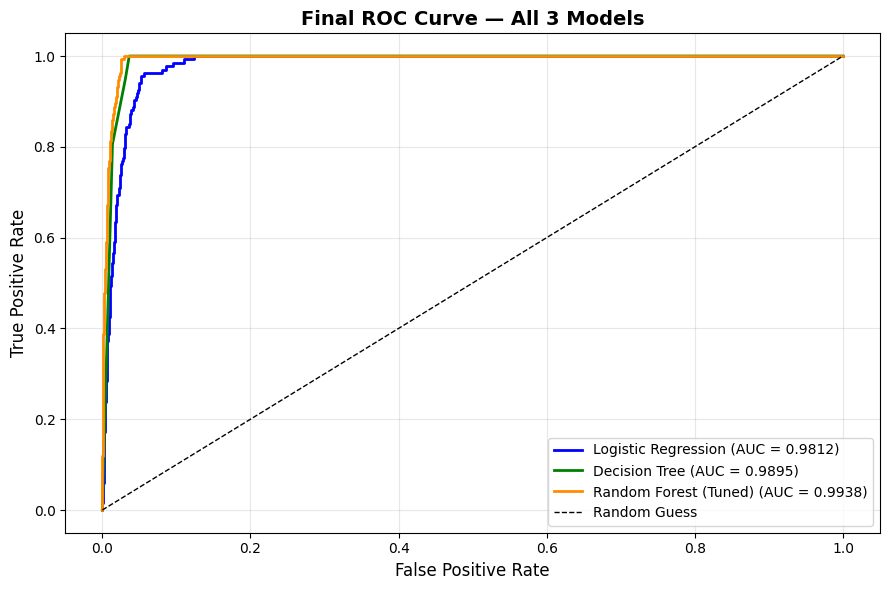

In [40]:
plt.figure(figsize=(9, 6))

for name, prob, color in [
    ('Logistic Regression',   y_prob_lr2,  'blue'),
    ('Decision Tree',         y_prob_dt2,  'green'),
    ('Random Forest (Tuned)', y_prob_rf2,  'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, color=color,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Final ROC Curve — All 3 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
